# 08 Final Comparison and Report

This notebook pulls together outputs from notebooks **03-07** into one final report.

Main steps:
1. check required artifacts
2. load metrics and saved outputs
3. build one comparison table
4. export markdown + figures


## Evaluation framing

To keep this fair:
- the winner is picked from the same held-out test split used in model notebooks
- rolling backtest and uncertainty are supporting robustness checks
- ablation results are used for sensitivity discussion, not to replace the main benchmark
- The canonical target throughout final comparisons is `target_yoy_t_plus_1` (next-month YoY CPI); MoM appears only in ablation sensitivity analysis.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import json
import shutil
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, Image

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.project_utils import ensure_project_dirs, seed_everything

seed_everything(42)
paths = ensure_project_dirs()

final_dir = paths["results"] / "final"
fig_dir = final_dir / "figures"
final_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
pd.options.display.max_columns = 200

print("Repo root:", ROOT)
print("Final report dir:", final_dir)
print("Figure dir:", fig_dir)


Repo root: C:\Users\User\Downloads\261-Project
Final report dir: C:\Users\User\Downloads\261-Project\results\final
Figure dir: C:\Users\User\Downloads\261-Project\results\final\figures


## 1) Artifact checks

In [2]:
ARTIFACTS = {
    # Classical baselines
    "baseline_metrics": paths["results"] / "baselines" / "baseline_metrics.json",
    "baseline_plot": paths["results"] / "baselines" / "best_baseline_actual_vs_pred.png",

    # LSTM
    "lstm_metrics": paths["results"] / "lstm" / "metrics.json",
    "lstm_plot": paths["results"] / "lstm" / "preds_vs_actuals.png",

    # XGBoost
    "xgb_metrics": paths["results"] / "xgb" / "metrics.json",
    "xgb_plot": paths["results"] / "xgb" / "preds_vs_actuals.png",
    "xgb_feature_importance_plot": paths["results"] / "xgb" / "feature_importance.png",

    # Backtest + uncertainty
    "backtest_metrics": paths["results"] / "backtest" / "backtest_metrics.json",
    "uncertainty_coverage": paths["results"] / "uncertainty" / "coverage.json",
    "uncertainty_plot": paths["results"] / "uncertainty" / "uncertainty_plot.png",

    # Ablation
    "ablation_results": paths["results"] / "ablations" / "ablation_results.csv",
    "ablation_summary": paths["results"] / "ablations" / "ablation_summary.md",
}

artifact_df = pd.DataFrame([
    {"artifact": name, "path": str(path.relative_to(ROOT)), "exists": path.exists()}
    for name, path in ARTIFACTS.items()
]).sort_values("artifact").reset_index(drop=True)

display(artifact_df)

missing = artifact_df.loc[~artifact_df["exists"], "artifact"].tolist()
if missing:
    missing_text = ", ".join(missing)
    raise FileNotFoundError(
        "Missing required upstream artifacts for notebook 08: "
        f"{missing_text}. Run notebooks 03-07 before this final report notebook."
    )

print("All required upstream artifacts are present.")


,artifact,path,exists
0,ablation_results,results\ablations\ablation_results.csv,True
1,ablation_summary,results\ablations\ablation_summary.md,True
2,backtest_metrics,results\backtest\backtest_metrics.json,True
3,baseline_metrics,results\baselines\baseline_metrics.json,True
4,baseline_plot,results\baselines\best_baseline_actual_vs_pred...,True
5,lstm_metrics,results\lstm\metrics.json,True
6,lstm_plot,results\lstm\preds_vs_actuals.png,True
7,uncertainty_coverage,results\uncertainty\coverage.json,True
8,uncertainty_plot,results\uncertainty\uncertainty_plot.png,True
9,xgb_feature_importance_plot,results\xgb\feature_importance.png,True


All required upstream artifacts are present.


## 2) Load metrics and upstream outputs

In [3]:
def read_json(path: Path) -> dict:

    return json.loads(path.read_text(encoding="utf-8"))



baseline_payload = read_json(ARTIFACTS["baseline_metrics"])

lstm_payload = read_json(ARTIFACTS["lstm_metrics"])

xgb_payload = read_json(ARTIFACTS["xgb_metrics"])

backtest_payload = read_json(ARTIFACTS["backtest_metrics"])

coverage_payload = read_json(ARTIFACTS["uncertainty_coverage"])

ablation_df = pd.read_csv(ARTIFACTS["ablation_results"]).sort_values("test_mae").reset_index(drop=True)



baseline_df = pd.DataFrame(baseline_payload["metrics"]).sort_values("mae").reset_index(drop=True)

backtest_windows_df = pd.DataFrame(backtest_payload.get("window_metrics", [])).copy()
if baseline_df.empty:
    raise ValueError("baseline_metrics.json has no model rows. Re-run notebook 03.")
if ablation_df.empty:
    raise ValueError("ablation_results.csv is empty. Re-run notebook 07.")



best_baseline = baseline_df.iloc[0].to_dict()

best_ablation = ablation_df.iloc[0].to_dict()



print("Best classical baseline:", best_baseline["model"])

print("Best ablation run:", best_ablation["run_id"])

print("Ablation target mode:", best_ablation["target_mode"])



display(baseline_df[["model", "mae", "smape", "mase"]])


Best classical baseline: NaiveLast
Best ablation run: A9
Ablation target mode: mom


,model,mae,smape,mase
0,NaiveLast,0.178702,6.368292,0.617544
1,"ARIMA(1,0,0)",0.316067,11.021485,1.092239
2,Lasso[mean_pooled],0.800670,28.126995,2.766889
3,SeasonalNaive,0.845264,24.189188,2.920992
4,Ridge[mean_pooled],1.135572,36.614728,3.924213


## 3) Final comparison table

This table combines:
- best classical baseline
- LSTM test metrics
- XGBoost test metrics
- XGBoost rolling backtest summary
- LSTM uncertainty coverage summary


In [4]:
comparison_rows = [
    {
        "section": "Classical baselines",
        "entry": str(best_baseline["model"]),
        "mae": float(best_baseline["mae"]),
        "smape": float(best_baseline["smape"]),
        "mase": float(best_baseline["mase"]),
        "coverage": np.nan,
        "avg_interval_width": np.nan,
        "evaluation_window": f"{baseline_payload['test_start']} to {baseline_payload['test_end']}",
        "notes": "Best row in baseline_metrics.json (naive, seasonal naive, ARIMA, Ridge, Lasso pool).",
    },
    {
        "section": "LSTM",
        "entry": str(lstm_payload.get("model_name", "stacked_lstm_nowcaster")),
        "mae": float(lstm_payload["metrics_test"]["mae"]),
        "smape": float(lstm_payload["metrics_test"]["smape"]),
        "mase": float(lstm_payload["metrics_test"]["mase"]),
        "coverage": np.nan,
        "avg_interval_width": np.nan,
        "evaluation_window": f"{lstm_payload['data']['test_start']} to {lstm_payload['data']['test_end']}",
        "notes": f"Stacked sequence model; lag={int(lstm_payload['config']['lag_length'])}.",
    },
    {
        "section": "XGBoost",
        "entry": f"selected={xgb_payload['selected_representation']}",
        "mae": float(xgb_payload["selected_representation_metrics"]["test"]["mae"]),
        "smape": float(xgb_payload["selected_representation_metrics"]["test"]["smape"]),
        "mase": float(xgb_payload["selected_representation_metrics"]["test"]["mase"]),
        "coverage": np.nan,
        "avg_interval_width": np.nan,
        "evaluation_window": f"{xgb_payload['data']['test_start']} to {xgb_payload['data']['test_end']}",
        "notes": f"Tabular model with {xgb_payload['selected_representation']} representation.",
    },
    {
        "section": "Rolling backtest summary",
        "entry": f"XGBoost walk-forward ({backtest_payload['n_windows']} windows)",
        "mae": float(backtest_payload["overall"]["mae"]),
        "smape": float(backtest_payload["overall"]["smape"]),
        "mase": float(backtest_payload["overall"]["mase"]),
        "coverage": np.nan,
        "avg_interval_width": np.nan,
        "evaluation_window": f"{backtest_windows_df['test_start'].min()} to {backtest_windows_df['test_end'].max()}",
        "notes": f"Step={int(backtest_payload['step'])} months; summary across rolling windows.",
    },
    {
        "section": "Uncertainty coverage summary",
        "entry": "LSTM MC-dropout interval",
        "mae": np.nan,
        "smape": np.nan,
        "mase": np.nan,
        "coverage": float(coverage_payload["mc_dropout"]["empirical_coverage"]),
        "avg_interval_width": float(coverage_payload["mc_dropout"]["avg_width"]),
        "evaluation_window": f"{coverage_payload['index_start']} to {coverage_payload['index_end']}",
        "notes": f"{int(coverage_payload['mc_dropout']['samples'])} stochastic passes, z={coverage_payload['mc_dropout']['z']}",
    },
    {
        "section": "Uncertainty coverage summary",
        "entry": "LSTM split-conformal interval",
        "mae": np.nan,
        "smape": np.nan,
        "mase": np.nan,
        "coverage": float(coverage_payload["split_conformal"]["empirical_coverage"]),
        "avg_interval_width": float(coverage_payload["split_conformal"]["avg_width"]),
        "evaluation_window": f"{coverage_payload['index_start']} to {coverage_payload['index_end']}",
        "notes": f"alpha={coverage_payload['alpha']}, calibration_n={coverage_payload['split_conformal']['calibration_size']}",
    },
]

comparison_df = pd.DataFrame(comparison_rows)

holdout_mask = comparison_df["section"].isin(["Classical baselines", "LSTM", "XGBoost"])
comparison_df.loc[holdout_mask, "holdout_mae_rank"] = (
    comparison_df.loc[holdout_mask, "mae"].rank(method="dense", ascending=True).astype(int)
)

# Markdown-friendly formatted copy
fmt_df = comparison_df.copy()

for col in ["mae", "smape", "mase", "coverage", "avg_interval_width"]:
    fmt_df[col] = fmt_df[col].map(lambda x: "-" if pd.isna(x) else f"{float(x):.4f}")

fmt_df["holdout_mae_rank"] = fmt_df["holdout_mae_rank"].map(lambda x: "-" if pd.isna(x) else str(int(x)))

display(comparison_df)

final_table_path = final_dir / "final_comparison_table.md"

header_lines = [
    "# Final Comparison Table",
    "",
    f"Generated UTC: {datetime.now(timezone.utc).isoformat()}",
    "",
    "This table aggregates hold-out metrics, rolling backtest summary, and interval coverage diagnostics.",
    "",
]

try:
    table_md = fmt_df.to_markdown(index=False)
except Exception:
    # Fallback markdown writer without optional deps
    cols = list(fmt_df.columns)
    rows = []
    rows.append("| " + " | ".join(cols) + " |")
    rows.append("| " + " | ".join(["---"] * len(cols)) + " |")
    for _, r in fmt_df.iterrows():
        rows.append("| " + " | ".join(str(r[c]) for c in cols) + " |")
    table_md = chr(10).join(rows)

final_table_path.write_text(chr(10).join(header_lines) + table_md + chr(10), encoding="utf-8")
print("Saved:", final_table_path)


,section,entry,mae,smape,mase,coverage,avg_interval_width,evaluation_window,notes,holdout_mae_rank
0,Classical baselines,NaiveLast,0.178702,6.368292,0.617544,NaN,NaN,2023-12-01 to 2026-01-01,"Best row in baseline_metrics.json (naive, seas...",2.0
1,LSTM,stacked_lstm_nowcaster,0.178713,6.561572,0.617581,NaN,NaN,2023-12-01 to 2026-01-01,Stacked sequence model; lag=24.,3.0
2,XGBoost,selected=mean_pooled,0.161352,5.831787,0.557586,NaN,NaN,2023-12-01 to 2026-01-01,Tabular model with mean_pooled representation.,1.0
3,Rolling backtest summary,XGBoost walk-forward (25 windows),0.300894,13.579407,1.467819,NaN,NaN,2019-07-01 to 2025-09-01,Step=3 months; summary across rolling windows.,NaN
4,Uncertainty coverage summary,LSTM MC-dropout interval,NaN,NaN,NaN,0.625,0.441574,2023-12-01 to 2026-01-01,"200 stochastic passes, z=1.96",NaN
5,Uncertainty coverage summary,LSTM split-conformal interval,NaN,NaN,NaN,1.000,1.847343,2023-12-01 to 2026-01-01,"alpha=0.1, calibration_n=24",NaN


Saved: C:\Users\User\Downloads\261-Project\results\final\final_comparison_table.md


## 4) Plot: held-out test comparison (classical vs LSTM vs XGBoost)

C:\Users\User\AppData\Local\Temp\ipykernel_32468\2047134194.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="model_label", y=metric, ax=ax, palette="deep")
C:\Users\User\AppData\Local\Temp\ipykernel_32468\2047134194.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="model_label", y=metric, ax=ax, palette="deep")
C:\Users\User\AppData\Local\Temp\ipykernel_32468\2047134194.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="model_label", y=metric, ax=ax, palette="deep")


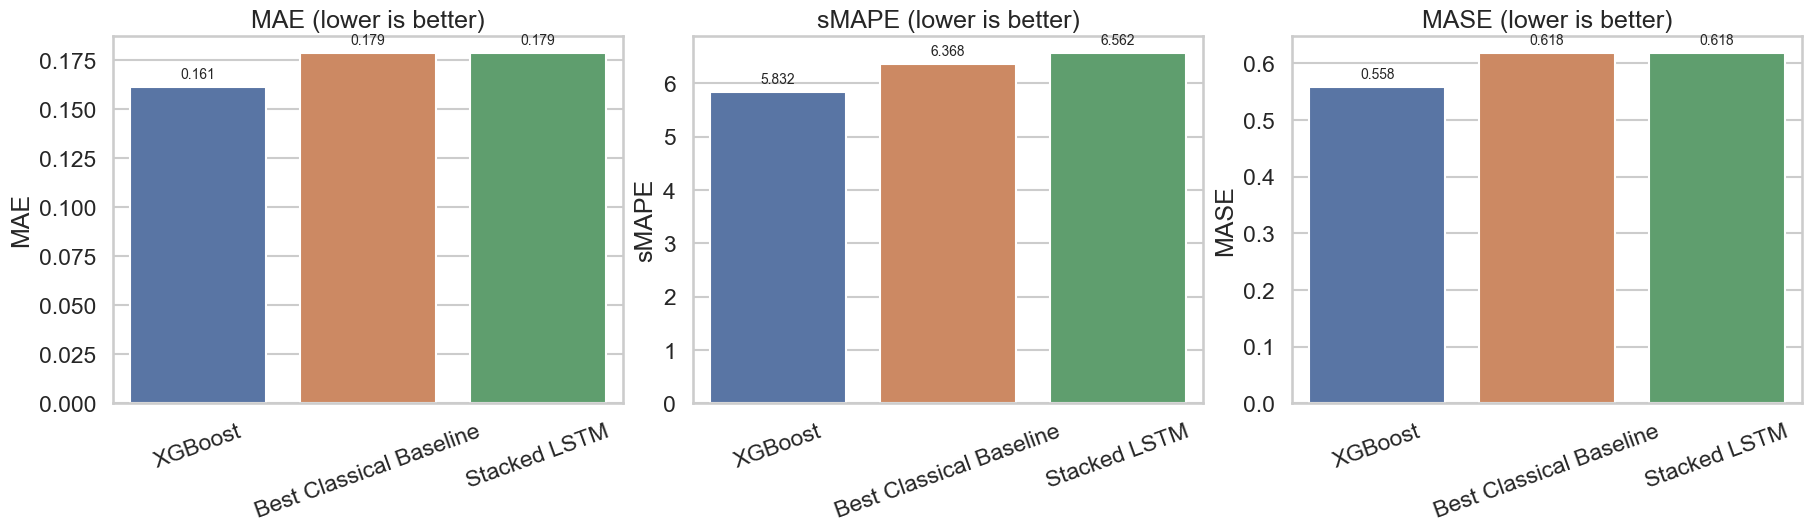

**Interpretation.** On the shared held-out window, **XGBoost (selected=mean_pooled)** is best (MAE=0.1614, sMAPE=5.8318, MASE=0.5576). Its MAE is about **9.7%** lower than the second-best model on this same split.

Saved: C:\Users\User\Downloads\261-Project\results\final\figures\holdout_metric_comparison.png


In [5]:
holdout_df = comparison_df.loc[comparison_df["section"].isin(["Classical baselines", "LSTM", "XGBoost"])].copy()
name_map = {
    "Classical baselines": "Best Classical Baseline",
    "LSTM": "Stacked LSTM",
    "XGBoost": "XGBoost",
}
holdout_df["model_label"] = holdout_df["section"].map(name_map)

metric_specs = [
    ("mae", "MAE"),
    ("smape", "sMAPE"),
    ("mase", "MASE"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), constrained_layout=True)
for ax, (metric, label) in zip(axes, metric_specs):
    plot_df = holdout_df.sort_values(metric, ascending=True)
    sns.barplot(data=plot_df, x="model_label", y=metric, ax=ax, palette="deep")
    ax.set_title(f"{label} (lower is better)")
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=20)
    for patch, value in zip(ax.patches, plot_df[metric].values):
        ax.annotate(f"{value:.3f}",
                    (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                    ha="center", va="bottom", fontsize=10, xytext=(0, 4), textcoords="offset points")

holdout_plot_path = fig_dir / "holdout_metric_comparison.png"
fig.savefig(holdout_plot_path, dpi=170, bbox_inches="tight")
plt.show()

winner = holdout_df.sort_values("mae").iloc[0]
runner_up = holdout_df.sort_values("mae").iloc[1]
mae_adv_pct = 100.0 * (runner_up["mae"] - winner["mae"]) / runner_up["mae"]

display(Markdown(
    f"**Interpretation.** On the shared held-out window, **{name_map[winner['section']]} ({winner['entry']})** is best "
    f"(MAE={winner['mae']:.4f}, sMAPE={winner['smape']:.4f}, MASE={winner['mase']:.4f}). "
    f"Its MAE is about **{mae_adv_pct:.1f}%** lower than the second-best model on this same split."
))

print("Saved:", holdout_plot_path)


## 5) Plot: rolling backtest stability (XGBoost)

This plot checks stability across windows, not just one split.


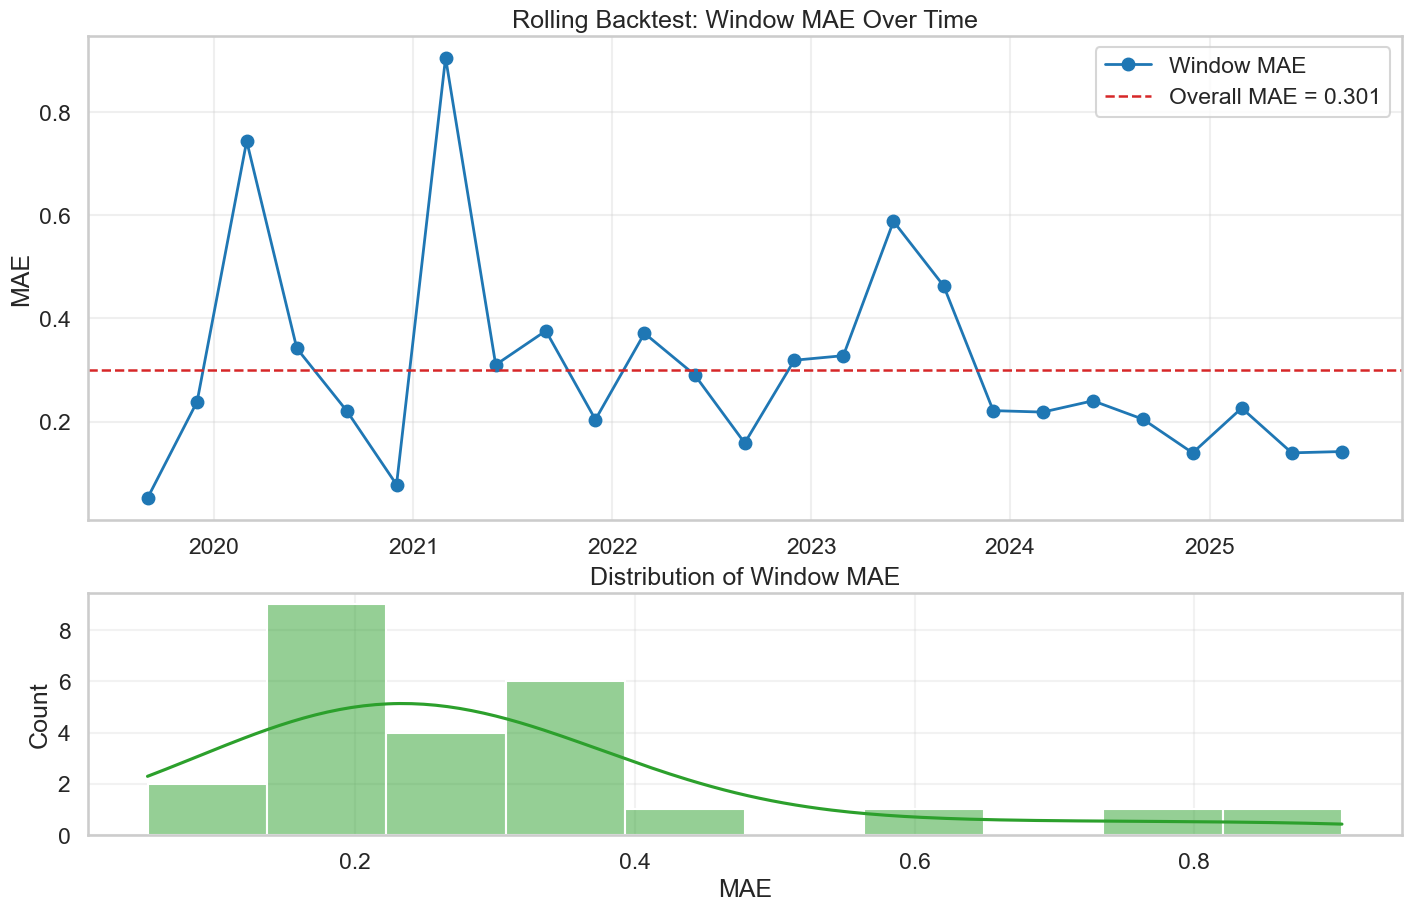

**Interpretation.** Backtest MAE ranges from **0.052** to **0.905**, with overall MAE **0.301** across 25 windows. Recent-window mean MAE (0.182) vs early-window mean MAE (0.279) highlights temporal variation in difficulty.

Saved: C:\Users\User\Downloads\261-Project\results\final\figures\rolling_backtest_summary.png


In [6]:
bt_df = backtest_windows_df.copy()
for c in ["test_start", "test_end", "train_end"]:
    bt_df[c] = pd.to_datetime(bt_df[c])

bt_df = bt_df.sort_values("window").reset_index(drop=True)
if bt_df.empty:
    raise ValueError("No rolling backtest windows found in backtest_metrics.json. Re-run notebook 06.")

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [2, 1]}, constrained_layout=True)

axes[0].plot(bt_df["test_end"], bt_df["mae"], marker="o", linewidth=2.0, color="#1f77b4", label="Window MAE")
axes[0].axhline(backtest_payload["overall"]["mae"], linestyle="--", color="#d62728", linewidth=1.8,
                label=f"Overall MAE = {backtest_payload['overall']['mae']:.3f}")
axes[0].set_title("Rolling Backtest: Window MAE Over Time")
axes[0].set_ylabel("MAE")
axes[0].grid(alpha=0.30)
axes[0].legend(loc="upper right")

sns.histplot(bt_df["mae"], bins=10, kde=True, ax=axes[1], color="#2ca02c")
axes[1].set_title("Distribution of Window MAE")
axes[1].set_xlabel("MAE")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.25)

backtest_plot_path = fig_dir / "rolling_backtest_summary.png"
fig.savefig(backtest_plot_path, dpi=170, bbox_inches="tight")
plt.show()

worst_window = bt_df.sort_values("mae", ascending=False).iloc[0]
best_window = bt_df.sort_values("mae", ascending=True).iloc[0]

recent_mean = bt_df.tail(6)["mae"].mean()
early_mean = bt_df.head(6)["mae"].mean()

display(Markdown(
    f"**Interpretation.** Backtest MAE ranges from **{best_window['mae']:.3f}** to **{worst_window['mae']:.3f}**, "
    f"with overall MAE **{backtest_payload['overall']['mae']:.3f}** across {backtest_payload['n_windows']} windows. "
    f"Recent-window mean MAE ({recent_mean:.3f}) vs early-window mean MAE ({early_mean:.3f}) highlights temporal variation in difficulty."
))

print("Saved:", backtest_plot_path)

## 6) Plot: uncertainty coverage

Coverage is compared to the nominal target (`1 - alpha`).


C:\Users\User\AppData\Local\Temp\ipykernel_32468\1397094568.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coverage_df, x="method", y="coverage", ax=axes[0], palette="deep")
C:\Users\User\AppData\Local\Temp\ipykernel_32468\1397094568.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coverage_df, x="method", y="avg_width", ax=axes[1], palette="muted")


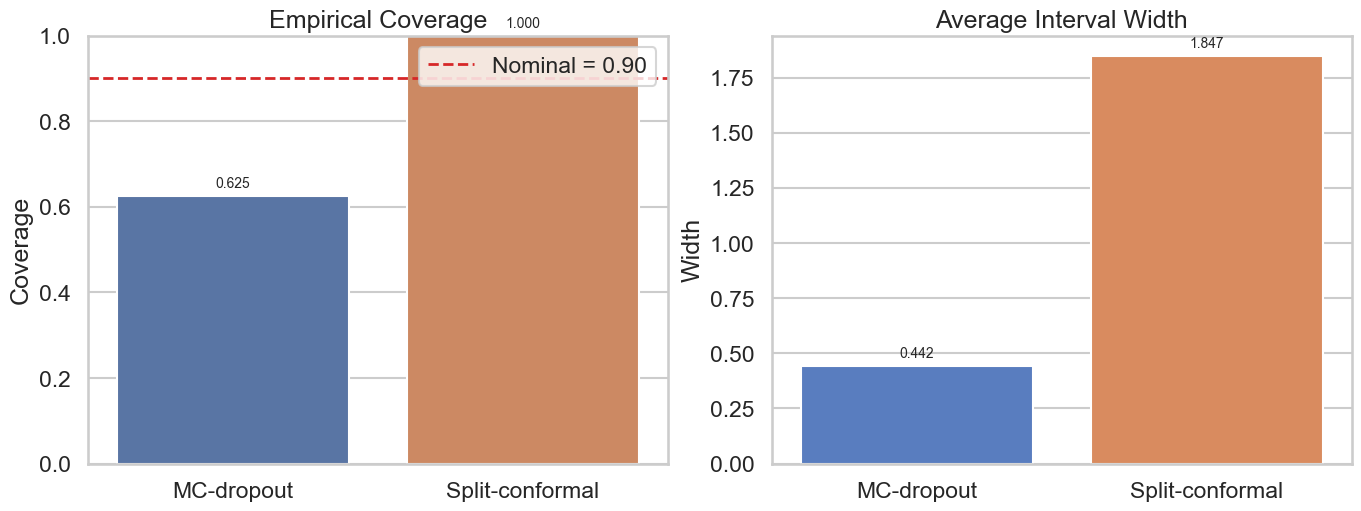

**Interpretation.** Coverage is not uniformly calibrated to the nominal 0.90 target. MC-dropout shows **under-coverage** (gap **+0.275**), while split-conformal shows **over-coverage** (gap **-0.100**).

Saved: C:\Users\User\Downloads\261-Project\results\final\figures\uncertainty_coverage_summary.png


In [7]:
nominal_cov = float(coverage_payload["nominal_coverage"])

coverage_df = pd.DataFrame([
    {
        "method": "MC-dropout",
        "coverage": float(coverage_payload["mc_dropout"]["empirical_coverage"]),
        "avg_width": float(coverage_payload["mc_dropout"]["avg_width"]),
    },
    {
        "method": "Split-conformal",
        "coverage": float(coverage_payload["split_conformal"]["empirical_coverage"]),
        "avg_width": float(coverage_payload["split_conformal"]["avg_width"]),
    },
])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0), constrained_layout=True)

sns.barplot(data=coverage_df, x="method", y="coverage", ax=axes[0], palette="deep")
axes[0].axhline(nominal_cov, color="#d62728", linestyle="--", linewidth=2, label=f"Nominal = {nominal_cov:.2f}")
axes[0].set_title("Empirical Coverage")
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Coverage")
axes[0].set_xlabel("")
axes[0].legend(loc="upper right")
for patch, value in zip(axes[0].patches, coverage_df["coverage"].values):
    axes[0].annotate(f"{value:.3f}",
                     (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                     ha="center", va="bottom", fontsize=10, xytext=(0, 4), textcoords="offset points")

sns.barplot(data=coverage_df, x="method", y="avg_width", ax=axes[1], palette="muted")
axes[1].set_title("Average Interval Width")
axes[1].set_ylabel("Width")
axes[1].set_xlabel("")
for patch, value in zip(axes[1].patches, coverage_df["avg_width"].values):
    axes[1].annotate(f"{value:.3f}",
                     (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                     ha="center", va="bottom", fontsize=10, xytext=(0, 4), textcoords="offset points")

uncertainty_plot_path = fig_dir / "uncertainty_coverage_summary.png"
fig.savefig(uncertainty_plot_path, dpi=170, bbox_inches="tight")
plt.show()

mc_gap = nominal_cov - float(coverage_payload["mc_dropout"]["empirical_coverage"])
conf_gap = nominal_cov - float(coverage_payload["split_conformal"]["empirical_coverage"])

def _gap_state(gap: float, tol: float = 0.02) -> str:
    if abs(gap) <= tol:
        return "near nominal"
    return "under-coverage" if gap > 0 else "over-coverage"

mc_state = _gap_state(mc_gap)
conf_state = _gap_state(conf_gap)

display(Markdown(
    f"**Interpretation.** Coverage is not uniformly calibrated to the nominal {nominal_cov:.2f} target. "
    f"MC-dropout shows **{mc_state}** (gap **{mc_gap:+.3f}**), while split-conformal shows **{conf_state}** "
    f"(gap **{conf_gap:+.3f}**)."
))

print("Saved:", uncertainty_plot_path)


## 7) Plot: target/lag sensitivity from ablations

Used for limitation/risk discussion in the final write-up.


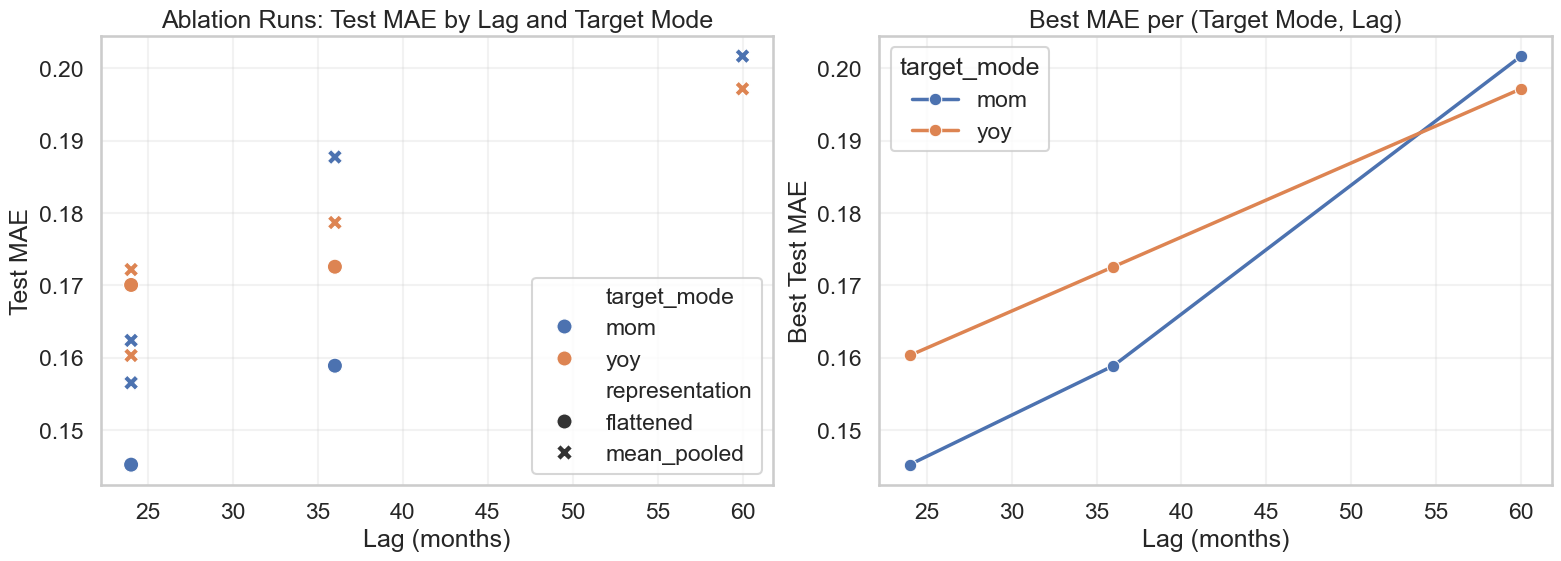

**Interpretation.** Ablation results show strong sensitivity to target definition and lag setup. Best run is `A9` with target `mom` and lag `24`. This reinforces that modeling conclusions depend materially on target specification choices.

Saved: C:\Users\User\Downloads\261-Project\results\final\figures\ablation_sensitivity_summary.png


In [8]:
ab_df = ablation_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.5), constrained_layout=True)

sns.scatterplot(
    data=ab_df,
    x="lag",
    y="test_mae",
    hue="target_mode",
    style="representation",
    s=120,
    ax=axes[0],
)
axes[0].set_title("Ablation Runs: Test MAE by Lag and Target Mode")
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Test MAE")
axes[0].grid(alpha=0.25)

summary_slice = (
    ab_df.groupby(["target_mode", "lag"], as_index=False)["test_mae"]
    .min()
    .sort_values(["target_mode", "lag"])
)

sns.lineplot(
    data=summary_slice,
    x="lag",
    y="test_mae",
    hue="target_mode",
    marker="o",
    linewidth=2.5,
    ax=axes[1],
)
axes[1].set_title("Best MAE per (Target Mode, Lag)")
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Best Test MAE")
axes[1].grid(alpha=0.25)

ablation_plot_path = fig_dir / "ablation_sensitivity_summary.png"
fig.savefig(ablation_plot_path, dpi=170, bbox_inches="tight")
plt.show()

best_by_target = ab_df.groupby("target_mode", as_index=False)["test_mae"].min().sort_values("test_mae")

display(Markdown(
    "**Interpretation.** Ablation results show strong sensitivity to target definition and lag setup. "
    f"Best run is `{best_ablation['run_id']}` with target `{best_ablation['target_mode']}` and lag `{int(best_ablation['lag'])}`. "
    "This reinforces that modeling conclusions depend materially on target specification choices."
))

print("Saved:", ablation_plot_path)


## 8) Final winner + limitations + export

In [9]:
# Winner based on strict shared hold-out comparison
holdout_ranked = holdout_df.sort_values("mae").reset_index(drop=True)
final_winner = holdout_ranked.iloc[0]
second_best = holdout_ranked.iloc[1]

winner_label = name_map[final_winner["section"]]
winner_entry = str(final_winner["entry"])
winner_mae = float(final_winner["mae"])
winner_smape = float(final_winner["smape"])
winner_mase = float(final_winner["mase"])

margin_abs = float(second_best["mae"] - final_winner["mae"])
margin_pct = 100.0 * margin_abs / float(second_best["mae"])

nominal_cov = float(coverage_payload["nominal_coverage"])
mc_cov = float(coverage_payload["mc_dropout"]["empirical_coverage"])
conf_cov = float(coverage_payload["split_conformal"]["empirical_coverage"])
mc_gap = nominal_cov - mc_cov
conf_gap = nominal_cov - conf_cov

def _gap_state(gap: float, tol: float = 0.02) -> str:
    if abs(gap) <= tol:
        return "near nominal"
    return "under-cover" if gap > 0 else "over-cover"

mc_state = _gap_state(mc_gap)
conf_state = _gap_state(conf_gap)

# Copy selected legacy figures for final presentation bundle
presentation_copies = {
    "baseline_actual_vs_pred.png": ARTIFACTS["baseline_plot"],
    "lstm_actual_vs_pred.png": ARTIFACTS["lstm_plot"],
    "xgb_actual_vs_pred.png": ARTIFACTS["xgb_plot"],
    "xgb_feature_importance.png": ARTIFACTS["xgb_feature_importance_plot"],
    "uncertainty_intervals.png": ARTIFACTS["uncertainty_plot"],
}

copied_targets = []
for target_name, src_path in presentation_copies.items():
    dst = fig_dir / target_name
    shutil.copy2(src_path, dst)
    copied_targets.append(dst)

summary_lines = []
summary_lines.append("# Final Project Summary")
summary_lines.append("")
summary_lines.append(f"Generated UTC: {datetime.now(timezone.utc).isoformat()}")
summary_lines.append("")
summary_lines.append("## Final Winner")
summary_lines.append(
    f"The final winner on the shared held-out benchmark is **{winner_label} ({winner_entry})** with "
    f"MAE={winner_mae:.4f}, sMAPE={winner_smape:.4f}, and MASE={winner_mase:.4f}."
)
summary_lines.append(
    f"Its MAE margin over the second-best model is {margin_abs:.4f} ({margin_pct:.1f}%)."
)
summary_lines.append("")
summary_lines.append("## Why this winner")
summary_lines.append("- It is selected using the same held-out period used by both LSTM and XGBoost notebooks.")
summary_lines.append("- It dominates all three core error metrics (MAE, sMAPE, MASE) on that shared split.")
summary_lines.append("- More complex models did not translate into lower out-of-sample error in this setup.")
summary_lines.append("")
summary_lines.append("## Rolling Backtest and Uncertainty Diagnostics")
summary_lines.append(
    f"- XGBoost rolling backtest overall metrics: MAE={backtest_payload['overall']['mae']:.4f}, "
    f"sMAPE={backtest_payload['overall']['smape']:.4f}, MASE={backtest_payload['overall']['mase']:.4f} "
    f"across {int(backtest_payload['n_windows'])} windows."
)
summary_lines.append(
    f"- Uncertainty calibration differs by method: MC-dropout coverage={mc_cov:.3f} ({mc_state}, gap={mc_gap:+.3f}), "
    f"split-conformal coverage={conf_cov:.3f} ({conf_state}, gap={conf_gap:+.3f}), "
    f"vs nominal={nominal_cov:.3f}."
)
summary_lines.append("")
summary_lines.append("## Limitations")
summary_lines.append("- **Small macro dataset**: monthly frequency and limited sample size constrain statistical power and deep-model reliability.")
summary_lines.append("- **Target-definition sensitivity**: ablations show substantial performance shifts across YoY vs MoM target formulations.")
summary_lines.append("- **Temporal instability**: rolling-window error varies across regimes, especially around macro turning points.")
summary_lines.append("- **Tree vs sequence limits**: tree models can miss temporal order effects; sequence models can overfit and be data-hungry in small samples.")
summary_lines.append(
    f"- **Uncertainty calibration caveats**: interval methods are miscalibrated relative to nominal "
    f"(MC-dropout {mc_state}, split-conformal {conf_state}), so risk bounds require recalibration."
)
summary_lines.append("")
summary_lines.append("## Recommended next iteration")
summary_lines.append("- Revisit target engineering and interval calibration first, then re-evaluate whether complexity beats strong naive baselines.")

final_summary_path = final_dir / "final_summary.md"
final_summary_path.write_text(chr(10).join(summary_lines) + chr(10), encoding="utf-8")

print("Winner:", winner_label)
print("Saved:", final_summary_path)
print("Copied presentation figures:")
for p in copied_targets:
    print("-", p)


Winner: XGBoost
Saved: C:\Users\User\Downloads\261-Project\results\final\final_summary.md
Copied presentation figures:
- C:\Users\User\Downloads\261-Project\results\final\figures\baseline_actual_vs_pred.png
- C:\Users\User\Downloads\261-Project\results\final\figures\lstm_actual_vs_pred.png
- C:\Users\User\Downloads\261-Project\results\final\figures\xgb_actual_vs_pred.png
- C:\Users\User\Downloads\261-Project\results\final\figures\xgb_feature_importance.png
- C:\Users\User\Downloads\261-Project\results\final\figures\uncertainty_intervals.png


## 9) Final verification

In [10]:
required_final_outputs = [
    final_dir / "final_comparison_table.md",
    final_dir / "final_summary.md",
    fig_dir / "holdout_metric_comparison.png",
    fig_dir / "rolling_backtest_summary.png",
    fig_dir / "uncertainty_coverage_summary.png",
    fig_dir / "ablation_sensitivity_summary.png",
    fig_dir / "baseline_actual_vs_pred.png",
    fig_dir / "lstm_actual_vs_pred.png",
    fig_dir / "xgb_actual_vs_pred.png",
    fig_dir / "xgb_feature_importance.png",
    fig_dir / "uncertainty_intervals.png",
]

final_checks_df = pd.DataFrame([
    {"path": str(p.relative_to(ROOT)), "exists": p.exists()} for p in required_final_outputs
])

display(final_checks_df)

missing_final = final_checks_df.loc[~final_checks_df["exists"], "path"].tolist()
if missing_final:
    raise FileNotFoundError("Missing final outputs: " + ", ".join(missing_final))

# Quick content checks for exported markdown
comparison_text = (final_dir / "final_comparison_table.md").read_text(encoding="utf-8")
summary_text = (final_dir / "final_summary.md").read_text(encoding="utf-8")

assert "Final Comparison Table" in comparison_text
assert "Final Winner" in summary_text
assert "Limitations" in summary_text

print("All final output files exist.")
print("Markdown content checks passed.")
print("Notebook 08 report pipeline verification: PASS")


,path,exists
0,results\final\final_comparison_table.md,True
1,results\final\final_summary.md,True
2,results\final\figures\holdout_metric_compariso...,True
3,results\final\figures\rolling_backtest_summary...,True
4,results\final\figures\uncertainty_coverage_sum...,True
5,results\final\figures\ablation_sensitivity_sum...,True
6,results\final\figures\baseline_actual_vs_pred.png,True
7,results\final\figures\lstm_actual_vs_pred.png,True
8,results\final\figures\xgb_actual_vs_pred.png,True
9,results\final\figures\xgb_feature_importance.png,True


All final output files exist.
Markdown content checks passed.
Notebook 08 report pipeline verification: PASS


Notebook 08 is expected to run top-to-bottom with no manual edits,
using saved outputs from notebooks 03-07.
